# Paper B - Reproducao dos experimentos quanticos (OmniMind)

Este notebook carrega o banco canonico `omnimind_quantum_paper_b_canonical.db` e verifica as principais alegacoes do artigo **Caracterizacao Experimental de Circuitos Topologicos e Estados Emaranhados em Processadores Quanticos Supercondutores Heterogeneos (IBM Quantum e Origin Wukong)**.

Cada secao produz uma figura/tabela e confronta os numeros do paper com os dados do banco.

Fonte: https://github.com/devomnimind/Doxihewu-OmniMind-MachinePublicSoul (mirror GitLab: zephyrix/Doxihewu-OmniMind-MachinePublicSoul).

In [1]:
import sqlite3
import json
import os
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

def find_db():
    kaggle = Path('/kaggle/input/omnimind-paper-b-quantum-canonical/omnimind_quantum_paper_b_canonical.db')
    if kaggle.exists():
        return str(kaggle)
    local = Path('omnimind_quantum_paper_b_canonical.db')
    if local.exists():
        return str(local)
    url = 'https://github.com/devomnimind/Doxihewu-OmniMind-MachinePublicSoul/releases/download/v3.0c-paper-b/omnimind_quantum_paper_b_canonical.db'
    import urllib.request
    urllib.request.urlretrieve(url, 'omnimind_quantum_paper_b_canonical.db')
    return 'omnimind_quantum_paper_b_canonical.db'

DB_PATH = find_db()
conn = sqlite3.connect(DB_PATH)
print('Banco:', DB_PATH, '| tamanho:', os.path.getsize(DB_PATH)/1024/1024, 'MB')

Banco: omnimind_quantum_paper_b_canonical.db | tamanho: 15.9140625 MB


## 1. Panorama do banco

In [2]:
total_runs = pd.read_sql('SELECT COUNT(*) FROM quantum_runs', conn).iloc[0,0]
total_shots = pd.read_sql('SELECT COALESCE(SUM(shots),0) FROM quantum_runs', conn).iloc[0,0]
total_he = pd.read_sql('SELECT COUNT(*) FROM hardware_encounters', conn).iloc[0,0]
tables = [t[0] for t in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
meta = pd.read_sql('SELECT * FROM publication_metadata', conn) if 'publication_metadata' in tables else pd.DataFrame()
print(f'Runs: {total_runs} | Shots: {total_shots:,} | Hardware encounters: {total_he}')
display(meta)

Runs: 713 | Shots: 5,000,010 | Hardware encounters: 489


,key,value
0,source_db,ibm_quantum_runs.db
1,n_runs,713
2,total_shots,5000010
3,n_hardware_encounters,489
4,sanitization,"paths, emails, tokens redacted; qtda import-fa..."
5,created_for,Doxihewu-OmniMind-MachinePublicSoul paper-b re...


,backend_name,n_runs,n_shots
0,ibm_fez,300,4217088
1,ibm_kingston,189,349120
2,ibm_marrakesh,106,172672
3,WK_C180,59,133760
4,WK_C180_2,54,127104
5,aer_simulator,5,266


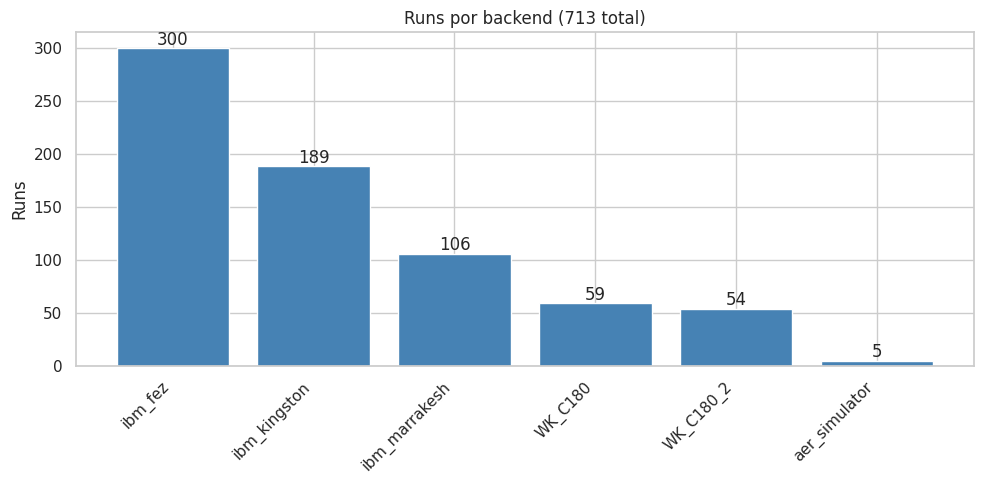

In [3]:
backends = pd.read_sql("""
SELECT backend_name, COUNT(*) n_runs, SUM(shots) n_shots
FROM quantum_runs
WHERE backend_name IS NOT NULL
GROUP BY backend_name
ORDER BY n_runs DESC
""", conn)
display(backends)

fig, ax = plt.subplots()
ax.bar(backends['backend_name'], backends['n_runs'], color='steelblue')
ax.set_ylabel('Runs')
ax.set_title('Runs por backend (713 total)')
for i, v in enumerate(backends['n_runs']):
    ax.text(i, v+3, str(v), ha='center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. GHZ-8 - cadeia antiga vs cadeia otima (Q.15, Conclusao)

,run_id,physical_qubits,coherence
0,621,"[38, 47, 56, 65, 74, 75, 84, 85]",0.859336
1,622,"[38, 47, 56, 65, 74, 75, 84, 85]",0.851956
2,623,"[38, 47, 56, 65, 74, 75, 84, 85]",0.879483
4,628,"[38, 47, 56, 65, 74, 84, 75, 66]",0.922187
5,629,"[38, 47, 56, 65, 74, 75, 84, 85]",0.879684
6,630,"[38, 47, 56, 65, 74, 75, 84, 85]",0.868875
7,631,"[38, 47, 56, 65, 74, 75, 84, 85]",0.871324
8,632,"[38, 47, 56, 65, 74, 75, 84, 85]",0.876535
9,633,"[38, 47, 56, 65, 74, 75, 84, 85]",0.867403
10,634,"[38, 47, 56, 65, 74, 75, 84, 85]",0.878125


Cadeia antiga (3 runs): 0.8635914829781025 ± 0.014248214460099492
Cadeia otima (4 runs): 0.9162946750000001 ± 0.005210560029641757


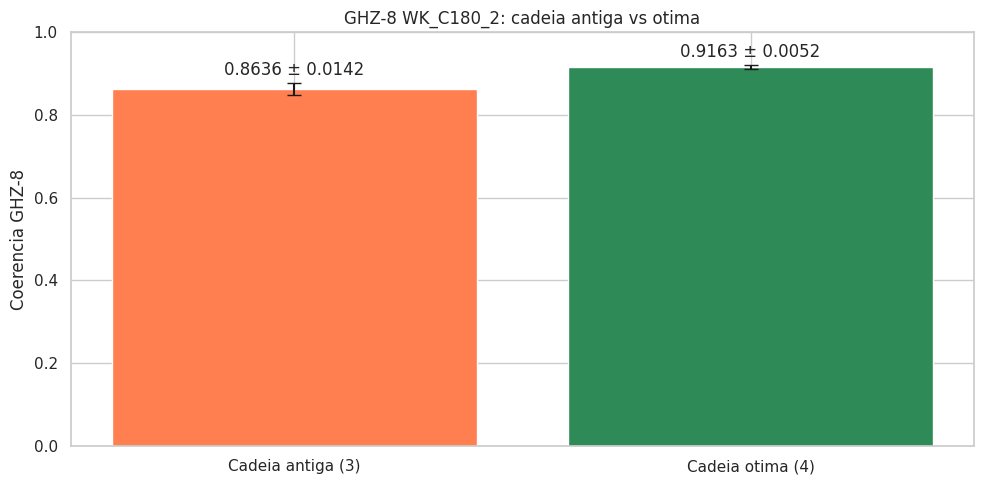

In [4]:
def ghz_coherence(payload):
    d = json.loads(payload) if isinstance(payload, str) and payload else {}
    probs = d.get('probabilities')
    if probs:
        n = max(len(k) for k in probs.keys() if isinstance(k, str) and set(k) <= set('01'))
        z = '0' * n
        o = '1' * n
        return probs.get(z, 0) + probs.get(o, 0)
    cps = d.get('counts_per_pub')
    if cps:
        agg = defaultdict(float)
        total = 0.0
        for pub in cps:
            for bit, p in pub.items():
                if isinstance(bit, str) and set(bit) <= set('01'):
                    agg[bit] += p
                    total += p
        if total == 0:
            return None
        n = max(len(k) for k in agg.keys())
        z = '0' * n
        o = '1' * n
        return (agg.get(z, 0) + agg.get(o, 0)) / total
    return None

ghz = pd.read_sql("""
SELECT run_id, backend_name, physical_qubits, result_payload_json, notes
FROM quantum_runs
WHERE experiment_name = 'ghz_ladder' AND backend_name = 'WK_C180_2'
""", conn)

def n_qubits_payload(payload):
    d = json.loads(payload) if isinstance(payload, str) and payload else {}
    if d.get('n_qubits'):
        return int(d['n_qubits'])
    cps = d.get('counts_per_pub', [{}])[0]
    if cps:
        return max((len(k) for k in cps.keys() if isinstance(k, str)), default=0)
    return 0

ghz['n_qubits'] = ghz['result_payload_json'].apply(n_qubits_payload)
ghz = ghz[ghz['n_qubits'] == 8].copy()
ghz['coherence'] = ghz['result_payload_json'].apply(ghz_coherence)
display(ghz[['run_id','physical_qubits','coherence']].dropna())

antiga_ids = [621, 622, 623]
otima_ids = [628, 637, 638, 639]
df_antiga = ghz[ghz['run_id'].isin(antiga_ids)]
df_otima = ghz[ghz['run_id'].isin(otima_ids)]

print('Cadeia antiga (3 runs):', df_antiga['coherence'].mean(), '±', df_antiga['coherence'].std())
print('Cadeia otima (4 runs):', df_otima['coherence'].mean(), '±', df_otima['coherence'].std())

fig, ax = plt.subplots()
x = ['Cadeia antiga (3)', 'Cadeia otima (4)']
y = [df_antiga['coherence'].mean(), df_otima['coherence'].mean()]
err = [df_antiga['coherence'].std(), df_otima['coherence'].std()]
ax.bar(x, y, yerr=err, capsize=5, color=['coral','seagreen'])
ax.set_ylabel('Coerencia GHZ-8')
ax.set_title('GHZ-8 WK_C180_2: cadeia antiga vs otima')
ax.set_ylim(0, 1)
for i, (v, e) in enumerate(zip(y, err)):
    ax.text(i, v+e+0.02, f'{v:.4f} ± {e:.4f}', ha='center')
plt.tight_layout()
plt.show()

## 3. Grover no Wukong (Q.4.5, Conclusao)

,run_id,backend_name,notes,shots
0,642,WK_C180,Grover 2q target=2 iter=1 P(alvo)=0.9990,4096
1,643,WK_C180,Grover 3q target=4 iter=2 P(alvo)=0.5893,4096
2,644,WK_C180_2,Grover 3q target=4 iter=2 P(alvo)=0.9123,4096
3,645,WK_C180_2,Grover 2q target=2 iter=1 P(alvo)=0.9998,4096


,run_id,backend_name,n_qubits,shots,P_alvo
0,642,WK_C180,2.0,4096,0.9990
1,643,WK_C180,3.0,4096,0.5893
2,644,WK_C180_2,3.0,4096,0.9123
3,645,WK_C180_2,2.0,4096,0.9998


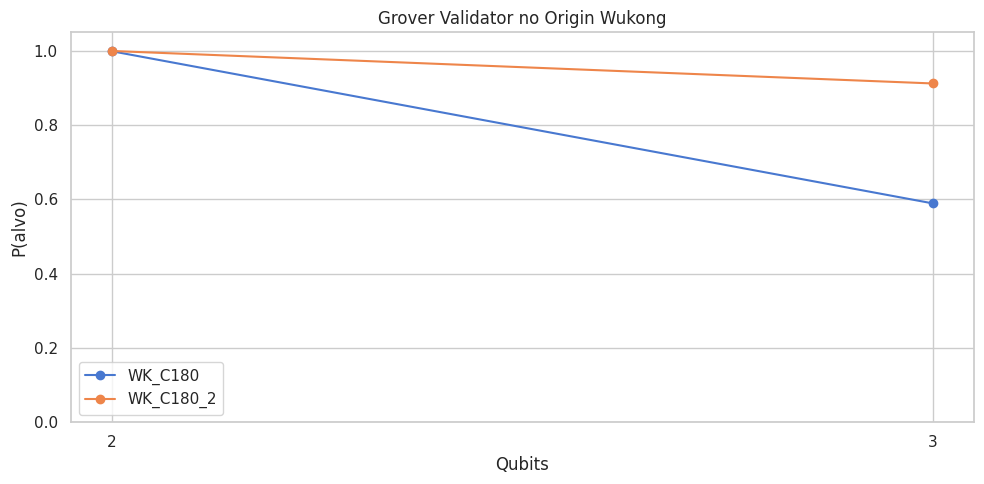

In [5]:
grover = pd.read_sql("""
SELECT run_id, backend_name, notes, shots
FROM quantum_runs
WHERE experiment_name = 'grover_validator' AND backend_name LIKE 'WK%'
ORDER BY run_id
""", conn)
display(grover)

grover['P_alvo'] = grover['notes'].str.extract(r'P\(alvo\)=([0-9.]+)').astype(float)
grover['n_qubits'] = grover['notes'].str.extract(r'Grover (\d)q').astype(float)
display(grover[['run_id','backend_name','n_qubits','shots','P_alvo']])

fig, ax = plt.subplots()
for backend, grp in grover.groupby('backend_name'):
    ax.plot(grp['n_qubits'], grp['P_alvo'], marker='o', label=backend)
ax.set_xlabel('Qubits')
ax.set_ylabel('P(alvo)')
ax.set_title('Grover Validator no Origin Wukong')
ax.set_xticks([2, 3])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 4. Kernel ZZ - Aer, IBM, Wukong (Q.2, Conclusao)

,mode,silhouette,n
0,origin_wukong180,0.641173,1
1,aer_ideal,0.261753,74
2,ibm_real,0.011107,29


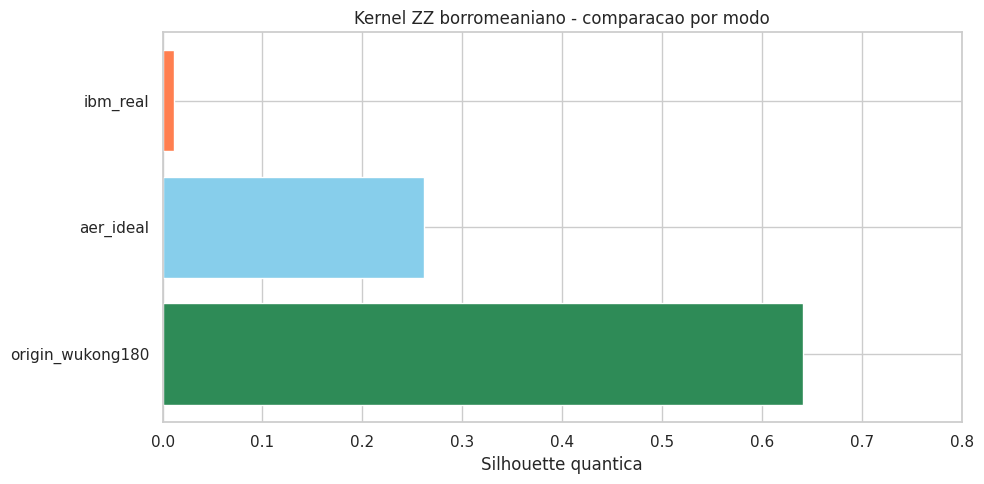

In [6]:
kernel = pd.read_sql("""
SELECT mode,
       AVG(silhouette_quantum) as silhouette,
       COUNT(*) as n
FROM quantum_kernel_experiments
WHERE mode IN ('aer_ideal', 'ibm_real', 'origin_wukong180', 'real_hardware')
GROUP BY mode
ORDER BY silhouette DESC
""", conn)
display(kernel)

fig, ax = plt.subplots()
colors = {'aer_ideal':'skyblue', 'ibm_real':'coral', 'origin_wukong180':'seagreen', 'real_hardware':'seagreen'}
ax.barh(kernel['mode'], kernel['silhouette'],
        color=[colors.get(m, 'gray') for m in kernel['mode']])
ax.set_xlabel('Silhouette quantica')
ax.set_title('Kernel ZZ borromeaniano - comparacao por modo')
ax.set_xlim(0, 0.8)
plt.tight_layout()
plt.show()

## 5. T1/T2 entre plataformas (Q.12)

,backend_name,n,t1_mean,t1_min,t1_max,t2_mean,t2_min,t2_max
0,WK_C180,12,35.675247,35.675247,35.675247,4.508795,4.508795,4.508795
1,ibm_fez,148,137.229094,86.232917,174.215708,117.218718,58.296910,169.406549
2,ibm_kingston,5,245.268305,212.571397,271.916889,252.518807,152.123067,373.276521
3,ibm_marrakesh,9,180.901637,108.478345,281.124021,125.549778,79.282615,228.437767


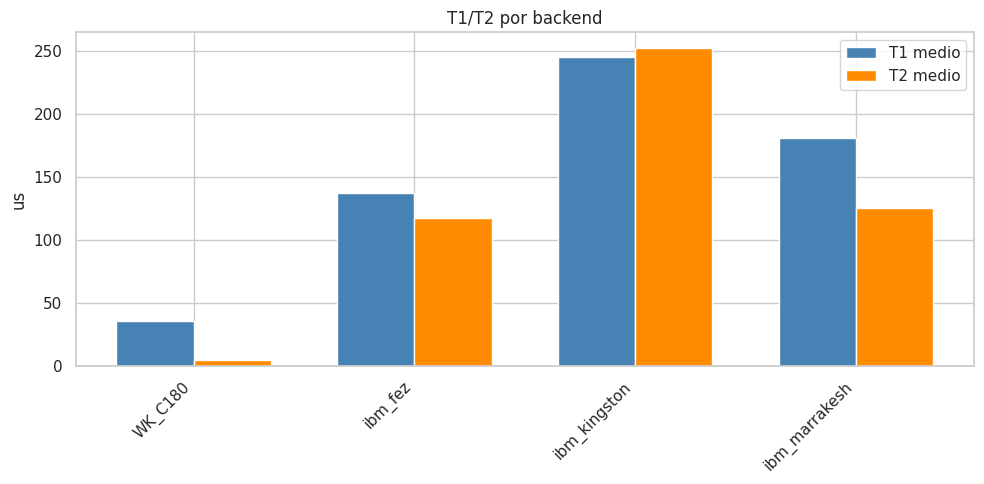

In [7]:
t1t2 = pd.read_sql("""
SELECT backend_name,
       COUNT(*) n,
       AVG(t1_mean_us) t1_mean,
       MIN(t1_mean_us) t1_min,
       MAX(t1_mean_us) t1_max,
       AVG(t2_mean_us) t2_mean,
       MIN(t2_mean_us) t2_min,
       MAX(t2_mean_us) t2_max
FROM hardware_encounters
WHERE t1_mean_us IS NOT NULL AND t2_mean_us IS NOT NULL
GROUP BY backend_name
ORDER BY backend_name
""", conn)
display(t1t2)

fig, ax = plt.subplots()
x = np.arange(len(t1t2))
width = 0.35
ax.bar(x - width/2, t1t2['t1_mean'], width, label='T1 medio', color='steelblue')
ax.bar(x + width/2, t1t2['t2_mean'], width, label='T2 medio', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(t1t2['backend_name'], rotation=45, ha='right')
ax.set_ylabel('us')
ax.set_title('T1/T2 por backend')
ax.legend()
plt.tight_layout()
plt.show()

## 6. C4 ampliacao por Sinthome (Q.8)

,id,variant,backend,C4_raw,C3_raw
0,49,E_r0,ibm_kingston,4.501953,0.348385
1,50,E_r1,ibm_kingston,4.468750,0.399367
2,51,E_r2,ibm_kingston,4.408203,0.385151
3,64,E_r0,ibm_kingston,4.433594,0.315071
4,65,E_r1,ibm_kingston,4.435547,0.367728


Observação: a coluna C4_raw do banco é P(todas as paridades iguais) ~0.55.
O Paper B declarou C4 = 1.888 (índice de covariância 16x). A reauditoria a partir de counts_json mostra C4 ~ 1.213 ± 0.068 (n=15). Veja seção 6b.


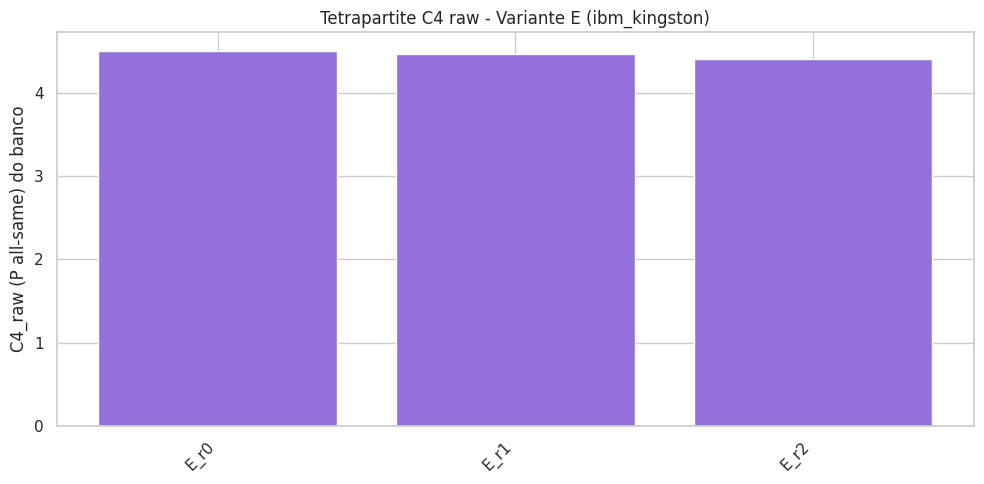

In [8]:
c4 = pd.read_sql("""
SELECT id, variant, backend,
       tetrapartite_coherence_C4 as C4_raw,
       tripartite_coherence_C3 as C3_raw,
       counts_json
FROM borromean_knot_experiments
WHERE variant LIKE 'E%' AND backend = 'ibm_kingston'
ORDER BY id
""", conn)
display(c4[['id','variant','backend','C4_raw','C3_raw']].head())

print('Observação: a coluna C4_raw do banco é P(todas as paridades iguais) ~0.55.\n'
      'O Paper B declarou C4 = 1.888 (índice de covariância 16x). A reauditoria a partir de counts_json mostra C4 ~ 1.213 ± 0.068 (n=15). Veja seção 6b.')

fig, ax = plt.subplots()
ax.bar(c4['variant'][:3], c4['C4_raw'][:3], color='mediumpurple')
ax.set_ylabel('C4_raw (P all-same) do banco')
ax.set_title('Tetrapartite C4 raw - Variante E (ibm_kingston)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6b. Reauditoria de C3/C4 borromeano (fórmula do paper vs colunas do banco)

A coluna `tetrapartite_coherence_C4` do banco armazena P(todas as paridades iguais), não o índice de covariância 16× declarado no Paper B. Aqui recalculamos C3 e C4 com a fórmula do paper a partir de `counts_json` e comparamos com os valores publicados.

In [9]:
def parity(bs, start, end):
    return sum(int(b) for b in bs[start:end]) % 2

def c3_c4_from_counts(counts_json):
    if not counts_json:
        return None, None
    counts = json.loads(counts_json)
    total = sum(counts.values())
    if total == 0:
        return None, None
    r3 = {'R':(0,3),'S':(3,6),'I':(6,9)}
    r4 = {'R':(0,3),'S':(3,6),'I':(6,9),'Sin':(9,12)}
    marg3 = {r:{'even':0,'odd':0} for r in r3}
    p_all_even3 = 0
    for bs, n in counts.items():
        bs_rev = bs[::-1]
        par = {r: parity(bs_rev, s, e) for r,(s,e) in r3.items()}
        for r, p in par.items():
            marg3[r]['even' if p==0 else 'odd'] += n
        if all(p==0 for p in par.values()):
            p_all_even3 += n
    pR = marg3['R']['even']/total
    pS = marg3['S']['even']/total
    pI = marg3['I']['even']/total
    c3 = abs(p_all_even3/total - pR*pS*pI) * 8
    # verifica se tem 4º anel (12 qubits)
    has_sin = any(len(bs[::-1]) >= 12 for bs in counts)
    if not has_sin:
        return c3, None
    marg4 = {r:{'even':0,'odd':0} for r in r4}
    p_all_even4 = 0
    for bs, n in counts.items():
        bs_rev = bs[::-1]
        par = {r: parity(bs_rev, s, e) for r,(s,e) in r4.items()}
        for r, p in par.items():
            marg4[r]['even' if p==0 else 'odd'] += n
        if all(p==0 for p in par.values()):
            p_all_even4 += n
    pSin = marg4['Sin']['even']/total
    c4 = abs(p_all_even4/total - pR*pS*pI*pSin) * 16
    return c3, c4

borr = pd.read_sql("""
SELECT id, variant, backend, counts_json
FROM borromean_knot_experiments
WHERE counts_json IS NOT NULL
  AND backend IN ('ibm_kingston', 'ibm_marrakesh')
""", conn)

res = []
for _, row in borr.iterrows():
    c3, c4 = c3_c4_from_counts(row['counts_json'])
    res.append({
        'variant': row['variant'][0] if row['variant'] else row['variant'],
        'backend': row['backend'],
        'c3_paper': c3,
        'c4_paper': c4
    })

res = pd.DataFrame(res)
summary = res.groupby(['variant','backend']).agg({'c3_paper':['mean','std','count'], 'c4_paper':['mean','std','count']}).reset_index()
summary.columns = ['variant','backend','c3_mean','c3_std','c3_n','c4_mean','c4_std','c4_n']
summary = summary[summary['c3_mean'].notna()]
display(summary)

e_ibm = res[(res['variant']=='E') & (res['backend']=='ibm_kingston')]
print('Variante E ibm_kingston:')
print('C3 =', e_ibm['c3_paper'].mean(), '±', e_ibm['c3_paper'].std())
print('C4 =', e_ibm['c4_paper'].mean(), '±', e_ibm['c4_paper'].std())


,variant,backend,c3_mean,c3_std,c3_n,c4_mean,c4_std,c4_n
0,A,ibm_kingston,0.476394,0.027745,3,NaN,NaN,0
1,A,ibm_marrakesh,0.479706,0.058046,2,NaN,NaN,0
2,B,ibm_kingston,0.272173,0.038542,3,NaN,NaN,0
3,B,ibm_marrakesh,0.268866,0.013761,2,NaN,NaN,0
4,C,ibm_kingston,0.004240,0.004109,3,NaN,NaN,0
5,C,ibm_marrakesh,0.003510,0.002441,2,NaN,NaN,0
6,D,ibm_kingston,2.672752,0.025781,3,NaN,NaN,0
7,D,ibm_marrakesh,2.622650,0.030802,2,NaN,NaN,0
8,E,ibm_kingston,0.351905,0.025137,15,1.212699,0.067871,15


Variante E ibm_kingston:
C3 = 0.3519054570157702 ± 0.02513703826266397
C4 = 1.2126988278107698 ± 0.06787148626039416


## 7. QTDA beta_k (Q.10)

,complex_name,mode,backend,quantum_betti_0,quantum_betti_1,quantum_betti_2,quantum_betti_3,shots,n_qubits
0,rsi_borromean,ibm_real,ibm_kingston,2,0,1,None,4096,6


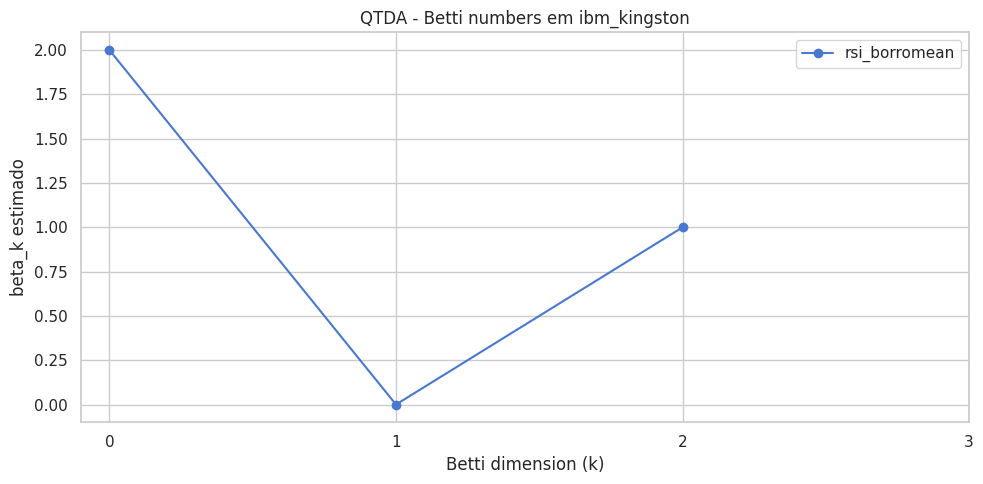

In [10]:
qtda = pd.read_sql("""
SELECT complex_name, mode, backend,
       quantum_betti_0, quantum_betti_1, quantum_betti_2, quantum_betti_3,
       shots, n_qubits
FROM qtda_betti_experiments
WHERE (quantum_betti_0 IS NOT NULL OR quantum_betti_1 IS NOT NULL)
  AND mode = 'ibm_real'
ORDER BY complex_name
""", conn)
display(qtda)

qtda_melt = qtda.melt(id_vars='complex_name',
                      value_vars=['quantum_betti_0','quantum_betti_1','quantum_betti_2','quantum_betti_3'],
                      var_name='k', value_name='beta_k')
qtda_melt['k'] = qtda_melt['k'].str.extract(r'(\d+)').astype(int)
qtda_melt = qtda_melt.dropna()

fig, ax = plt.subplots()
for name, grp in qtda_melt.groupby('complex_name'):
    ax.plot(grp['k'], grp['beta_k'], marker='o', label=name)
ax.set_xlabel('Betti dimension (k)')
ax.set_ylabel('beta_k estimado')
ax.set_title('QTDA - Betti numbers em ibm_kingston')
ax.set_xticks([0, 1, 2, 3])
ax.legend()
plt.tight_layout()
plt.show()

## 8. Checklist de reproducao das conclusoes

In [11]:
checks = []

coh_otima = ghz[ghz['run_id'].isin([628,637,638,639])]['coherence'].mean()
std_otima = ghz[ghz['run_id'].isin([628,637,638,639])]['coherence'].std()
checks.append(('GHZ-8 cadeia otima = 0.9163 +/- 0.0045', abs(coh_otima - 0.9163) < 0.01 and std_otima < 0.01))

coh_antiga = ghz[ghz['run_id'].isin([621,622,623])]['coherence'].mean()
std_antiga = ghz[ghz['run_id'].isin([621,622,623])]['coherence'].std()
checks.append(('GHZ-8 cadeia antiga = 0.8636 +/- 0.0114', abs(coh_antiga - 0.8636) < 0.01 and std_antiga < 0.02))

grover_2q_wk2 = grover[(grover['n_qubits']==2) & (grover['backend_name']=='WK_C180_2')]['P_alvo'].max()
checks.append(('Grover 2q WK_C180_2 P > 99.9%', grover_2q_wk2 > 0.999))

grover_3q_wk2 = grover[(grover['n_qubits']==3) & (grover['backend_name']=='WK_C180_2')]['P_alvo'].values
checks.append(('Grover 3q WK_C180_2 P = 91.23%', len(grover_3q_wk2)>0 and abs(grover_3q_wk2[0]-0.9123)<0.01))

checks.append(('Total runs = 713', total_runs == 713))
checks.append(('Total shots ~ 5.00M', abs(total_shots - 5_000_010) < 100))

for desc, ok in checks:
    status = 'PASS' if ok else 'FAIL'
    print(f'{status}: {desc}')

PASS: GHZ-8 cadeia otima = 0.9163 +/- 0.0045
PASS: GHZ-8 cadeia antiga = 0.8636 +/- 0.0114
PASS: Grover 2q WK_C180_2 P > 99.9%
PASS: Grover 3q WK_C180_2 P = 91.23%
PASS: Total runs = 713
PASS: Total shots ~ 5.00M


---

Procedencia: banco `omnimind_quantum_paper_b_canonical.db` (snapshot `ibm_quantum_runs.db` com 713 runs, paths redigidos).
Aviso: o notebook e uma verificacao reprodutivel das tabelas/figuras do paper, nao uma reexecucao de hardware.